In [1]:
import lsdb
from lsdb.streams import CatalogStream
import numpy as np

from distributed.diagnostics import MemorySampler

import dask
dask.config.set({"temporary-directory" :'/astro/store/epyc/users/brantd/tmp'})

In [ ]:
from dask.distributed import Client

# Will be used implicitly for all distributed operations
client = Client(n_workers=2, memory_limit="12GB", dashboard_address=":8235", threads_per_worker=1)
client

## Delayed Streaming Optimization

In [35]:
from dask.optimization import cull
from dask.delayed import Delayed

gaia = lsdb.open_catalog(
    "/astro/store/epyc3/data3/hats/catalogs/gaia_dr3",
    #"https://data.lsdb.io/hats/ztf_dr22",
    search_filter=lsdb.ConeSearch(ra=254.5, dec=35.3, radius_arcsec=50000, fine=True),
)
# Streaming Graph Optimization

# Optimization 1: Using delayed tasks
raw_delayed = gaia.to_delayed(optimize_graph=True)

# Optimization 2: Manual Graph Culling
shared_graph = dict(raw_delayed[0].__dask_graph__())
delayed_partitions = []
for d in raw_delayed:
    culled_graph, _ = cull(shared_graph, list(d.__dask_keys__()))
    delayed_partitions.append(Delayed(d.key, culled_graph))

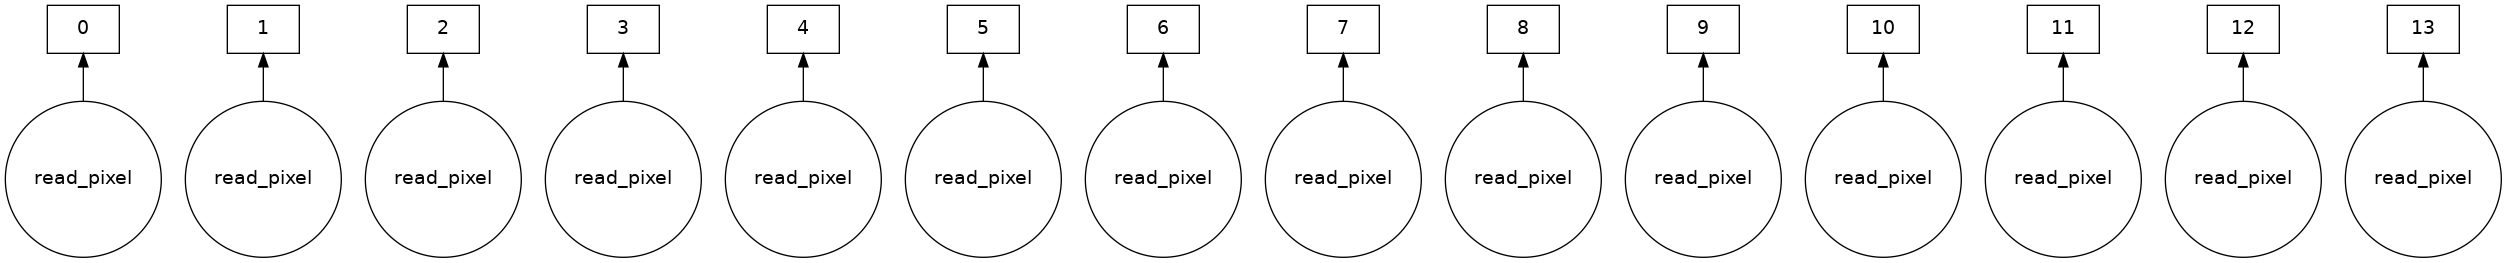

In [37]:
# Original Graph
raw_delayed[0].visualize()

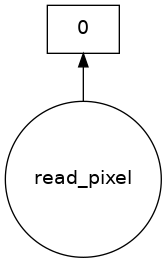

In [38]:
# Culled Graph
delayed_partitions[0].visualize()

## Retrieve First Row Workflow

In [ ]:
gaia = lsdb.open_catalog(
    "/astro/store/epyc3/data3/hats/catalogs/gaia_dr3",
    #"https://data.lsdb.io/hats/ztf_dr22",
    search_filter=lsdb.ConeSearch(ra=254.5, dec=35.3, radius_arcsec=150000, fine=True),
)

def first_row(nf):
    return nf.head(1)

gaia_first = gaia.map_partitions(first_row)
gaia_first

In [ ]:
ms = MemorySampler()

ppc = [2, 4, 250]
for ppc_val in ppc:
    client.restart()
    gaia_stream = CatalogStream(gaia_first, partitions_per_chunk=ppc_val, shuffle=False)
    with ms.sample(f"stream (ppc={ppc_val})"):
        for i,chunk in enumerate(gaia_stream):
            continue

client.restart()
with ms.sample("compute"):
    gaia_first.compute()

Text(0.5, 1.0, 'Retrieve First Row From 250 Gaia Partitions (2 Workers, 12GB per)')

<Figure size 960x720 with 0 Axes>

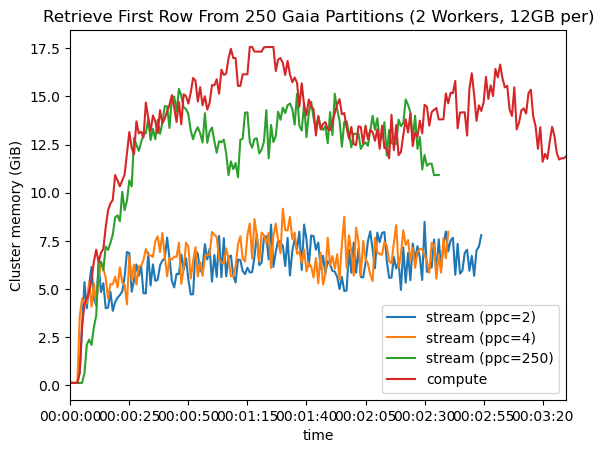

In [37]:
import matplotlib.pyplot as plt
fig = plt.figure(dpi=150)

ms.plot(align=True)
ax = plt.gca()
ax.set_title("Retrieve First Row From 250 Gaia Partitions (2 Workers, 12GB per)")

## Open Catalog - More Memory

In [ ]:
from dask.distributed import Client

# Will be used implicitly for all distributed operations
client = Client(n_workers=2, memory_limit="24GB", dashboard_address=":8235", threads_per_worker=1)
client

ms_moremem = MemorySampler()

ppc = [2, 4, 250]
for ppc_val in ppc:
    client.restart()
    gaia_stream = CatalogStream(gaia_first, partitions_per_chunk=ppc_val, shuffle=False)
    with ms_moremem.sample(f"stream (ppc={ppc_val})"):
        for i,chunk in enumerate(gaia_stream):
            continue

client.restart()
with ms_moremem.sample("compute"):
    gaia_first.compute()

Text(0.5, 1.0, 'Retrieve First Row From 250 Gaia Partitions (2 Workers, 24GB per)')

<Figure size 960x720 with 0 Axes>

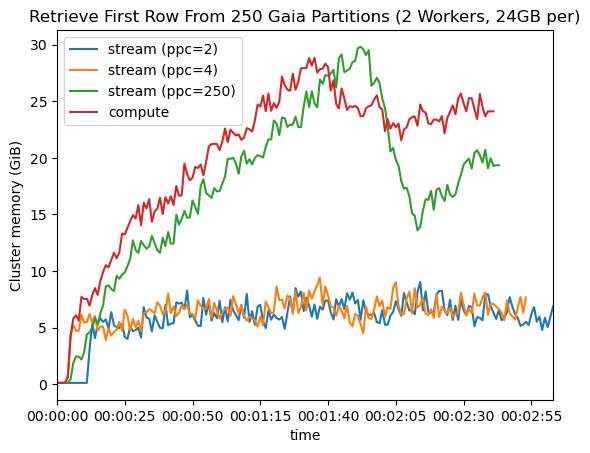

In [4]:
import matplotlib.pyplot as plt
fig = plt.figure(dpi=150)

ms_moremem.plot(align=True)
ax = plt.gca()
ax.set_title("Retrieve First Row From 250 Gaia Partitions (2 Workers, 24GB per)")

## Open Catalog - http

In [5]:
gaia_http = lsdb.open_catalog(
    "https://data.lsdb.io/hats/gaia_dr3",
    search_filter=lsdb.ConeSearch(ra=254.5, dec=35.3, radius_arcsec=150000, fine=True),
)

def first_row(nf):
    return nf.head(1)

gaia_first_http = gaia_http.map_partitions(first_row)
gaia_first_http

,solution_id,designation,source_id,random_index,ref_epoch,ra,ra_error,dec,dec_error,parallax,parallax_error,parallax_over_error,pm,pmra,pmra_error,pmdec,pmdec_error,ra_dec_corr,ra_parallax_corr,ra_pmra_corr,ra_pmdec_corr,dec_parallax_corr,dec_pmra_corr,dec_pmdec_corr,parallax_pmra_corr,parallax_pmdec_corr,pmra_pmdec_corr,astrometric_n_obs_al,astrometric_n_obs_ac,astrometric_n_good_obs_al,astrometric_n_bad_obs_al,astrometric_gof_al,astrometric_chi2_al,astrometric_excess_noise,astrometric_excess_noise_sig,astrometric_params_solved,astrometric_primary_flag,nu_eff_used_in_astrometry,pseudocolour,pseudocolour_error,ra_pseudocolour_corr,dec_pseudocolour_corr,parallax_pseudocolour_corr,pmra_pseudocolour_corr,pmdec_pseudocolour_corr,astrometric_matched_transits,visibility_periods_used,astrometric_sigma5d_max,matched_transits,new_matched_transits,matched_transits_removed,ipd_gof_harmonic_amplitude,ipd_gof_harmonic_phase,ipd_frac_multi_peak,ipd_frac_odd_win,ruwe,scan_direction_strength_k1,scan_direction_strength_k2,scan_direction_strength_k3,scan_direction_strength_k4,scan_direction_mean_k1,scan_direction_mean_k2,scan_direction_mean_k3,scan_direction_mean_k4,duplicated_source,phot_g_n_obs,phot_g_mean_flux,phot_g_mean_flux_error,phot_g_mean_flux_over_error,phot_g_mean_mag,phot_bp_n_obs,phot_bp_mean_flux,phot_bp_mean_flux_error,phot_bp_mean_flux_over_error,phot_bp_mean_mag,phot_rp_n_obs,phot_rp_mean_flux,phot_rp_mean_flux_error,phot_rp_mean_flux_over_error,phot_rp_mean_mag,phot_bp_rp_excess_factor,phot_bp_n_contaminated_transits,phot_bp_n_blended_transits,phot_rp_n_contaminated_transits,phot_rp_n_blended_transits,phot_proc_mode,bp_rp,bp_g,g_rp,radial_velocity,radial_velocity_error,rv_method_used,rv_nb_transits,rv_nb_deblended_transits,rv_visibility_periods_used,rv_expected_sig_to_noise,rv_renormalised_gof,rv_chisq_pvalue,rv_time_duration,rv_amplitude_robust,rv_template_teff,rv_template_logg,rv_template_fe_h,rv_atm_param_origin,vbroad,vbroad_error,vbroad_nb_transits,grvs_mag,grvs_mag_error,grvs_mag_nb_transits,rvs_spec_sig_to_noise,phot_variable_flag,l,b,ecl_lon,ecl_lat,in_qso_candidates,in_galaxy_candidates,non_single_star,has_xp_continuous,has_xp_sampled,has_rvs,has_epoch_photometry,has_epoch_rv,has_mcmc_gspphot,has_mcmc_msc,in_andromeda_survey,classprob_dsc_combmod_quasar,classprob_dsc_combmod_galaxy,classprob_dsc_combmod_star,teff_gspphot,teff_gspphot_lower,teff_gspphot_upper,logg_gspphot,logg_gspphot_lower,logg_gspphot_upper,mh_gspphot,mh_gspphot_lower,mh_gspphot_upper,distance_gspphot,distance_gspphot_lower,distance_gspphot_upper,azero_gspphot,azero_gspphot_lower,azero_gspphot_upper,ag_gspphot,ag_gspphot_lower,ag_gspphot_upper,ebpminrp_gspphot,ebpminrp_gspphot_lower,ebpminrp_gspphot_upper,libname_gspphot
npartitions=250,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
"Order: 2, Pixel: 32",int64[pyarrow],string[pyarrow],int64[pyarrow],int64[pyarrow],double[pyarrow],double[pyarrow],float[pyarrow],double[pyarrow],float[pyarrow],double[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],double[pyarrow],float[pyarrow],double[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int8[pyarrow],bool[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int16[pyarrow],int16[pyarrow],float[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],float[pyarrow],float[pyarrow],int8[pyarrow],int8[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],bool[pyarrow],int16[pyarrow],double[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int16[pyar

In [ ]:
ms_http = MemorySampler()

ppc = [2, 4, 250]
for ppc_val in ppc:
    client.restart()
    gaia_stream = CatalogStream(gaia_first_http, partitions_per_chunk=ppc_val, shuffle=False)
    with ms_http.sample(f"stream (ppc={ppc_val})"):
        for i,chunk in enumerate(gaia_stream):
            continue

client.restart()
with ms_http.sample("compute"):
    gaia_first_http.compute()

Text(0.5, 1.0, 'Retrieve First Row From 250 Gaia Partitions (2 Workers, 12GB per, over http)')

<Figure size 960x720 with 0 Axes>

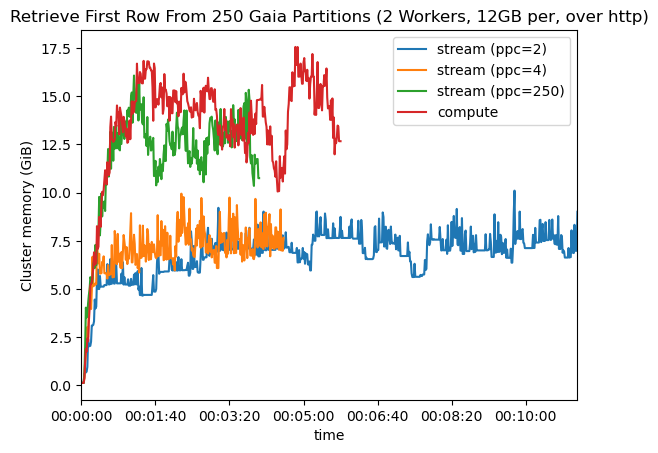

In [7]:
import matplotlib.pyplot as plt
fig = plt.figure(dpi=150)

ms_http.plot(align=True)
ax = plt.gca()
ax.set_title("Retrieve First Row From 250 Gaia Partitions (2 Workers, 12GB per, over http)")

## Crossmatch

In [10]:
gaia = lsdb.open_catalog(
    "/astro/store/epyc3/data3/hats/catalogs/gaia_dr3",
    #"https://data.lsdb.io/hats/ztf_dr22",
    search_filter=lsdb.ConeSearch(ra=254.5, dec=35.3, radius_arcsec=300000, fine=True),
)

desi = lsdb.open_catalog(
    "/astro/store/epyc3/data3/hats/catalogs/desi/desi_dr1_zcat",
    #"https://data.lsdb.io/hats/ztf_dr22",
    search_filter=lsdb.ConeSearch(ra=254.5, dec=35.3, radius_arcsec=300000, fine=True),
)

xmatch = gaia.crossmatch(desi, suffix_method='overlapping_columns')

def first_row(nf):
    return nf.head(1)

xmatch_first = xmatch.map_partitions(first_row)
xmatch

,solution_id,designation,source_id,random_index,ref_epoch,ra,ra_error,dec,dec_error,parallax,parallax_error,parallax_over_error,pm,pmra,pmra_error,pmdec,pmdec_error,ra_dec_corr,ra_parallax_corr,ra_pmra_corr,ra_pmdec_corr,dec_parallax_corr,dec_pmra_corr,dec_pmdec_corr,parallax_pmra_corr,parallax_pmdec_corr,pmra_pmdec_corr,astrometric_n_obs_al,astrometric_n_obs_ac,astrometric_n_good_obs_al,astrometric_n_bad_obs_al,astrometric_gof_al,astrometric_chi2_al,astrometric_excess_noise,astrometric_excess_noise_sig,astrometric_params_solved,astrometric_primary_flag,nu_eff_used_in_astrometry,pseudocolour,pseudocolour_error,ra_pseudocolour_corr,dec_pseudocolour_corr,parallax_pseudocolour_corr,pmra_pseudocolour_corr,pmdec_pseudocolour_corr,astrometric_matched_transits,visibility_periods_used,astrometric_sigma5d_max,matched_transits,new_matched_transits,matched_transits_removed,ipd_gof_harmonic_amplitude,ipd_gof_harmonic_phase,ipd_frac_multi_peak,ipd_frac_odd_win,ruwe,scan_direction_strength_k1,scan_direction_strength_k2,scan_direction_strength_k3,scan_direction_strength_k4,scan_direction_mean_k1,scan_direction_mean_k2,scan_direction_mean_k3,scan_direction_mean_k4,duplicated_source,phot_g_n_obs,phot_g_mean_flux,phot_g_mean_flux_error,phot_g_mean_flux_over_error,phot_g_mean_mag,phot_bp_n_obs,phot_bp_mean_flux,phot_bp_mean_flux_error,phot_bp_mean_flux_over_error,phot_bp_mean_mag,phot_rp_n_obs,phot_rp_mean_flux,phot_rp_mean_flux_error,phot_rp_mean_flux_over_error,phot_rp_mean_mag,phot_bp_rp_excess_factor,phot_bp_n_contaminated_transits,phot_bp_n_blended_transits,phot_rp_n_contaminated_transits,phot_rp_n_blended_transits,phot_proc_mode,bp_rp,bp_g,g_rp,radial_velocity,radial_velocity_error,rv_method_used,rv_nb_transits,rv_nb_deblended_transits,rv_visibility_periods_used,rv_expected_sig_to_noise,rv_renormalised_gof,rv_chisq_pvalue,rv_time_duration,rv_amplitude_robust,rv_template_teff,rv_template_logg,rv_template_fe_h,rv_atm_param_origin,vbroad,vbroad_error,vbroad_nb_transits,grvs_mag,grvs_mag_error,grvs_mag_nb_transits,rvs_spec_sig_to_noise,phot_variable_flag,l,b,ecl_lon,ecl_lat,in_qso_candidates,in_galaxy_candidates,non_single_star,has_xp_continuous,has_xp_sampled,has_rvs,has_epoch_photometry,has_epoch_rv,has_mcmc_gspphot,has_mcmc_msc,in_andromeda_survey,classprob_dsc_combmod_quasar,classprob_dsc_combmod_galaxy,classprob_dsc_combmod_star,teff_gspphot,teff_gspphot_lower,teff_gspphot_upper,logg_gspphot,logg_gspphot_lower,logg_gspphot_upper,mh_gspphot,mh_gspphot_lower,mh_gspphot_upper,distance_gspphot,distance_gspphot_lower,distance_gspphot_upper,azero_gspphot,azero_gspphot_lower,azero_gspphot_upper,ag_gspphot,ag_gspphot_lower,ag_gspphot_upper,ebpminrp_gspphot,ebpminrp_gspphot_lower,ebpminrp_gspphot_upper,libname_gspphot,TARGETID,SURVEY,PROGRAM,HEALPIX,SPGRPVAL,Z,ZERR,ZWARN,CHI2,COEFF,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,COADD_FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,FA_TARGET,FA_TYPE,OBJTYPE,SUBPRIORITY,OBSCONDITIONS,RELEASE,BRICKNAME,BRICKID,BRICK_OBJID,MORPHTYPE,EBV,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,FLUX_W2,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,FLUX_IVAR_W1,FLUX_IVAR_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,PHOTSYS,PRIORITY_INIT,NUMOBS_INIT,CMX_TARGET,DESI_TARGET,BGS_TARGET,MWS_TARGET,SCND_TARGET,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,SV1_SCND_TARGET,SV2_DESI_TARGET,SV2_BGS_TARGET,SV2_MWS_TARGET,SV2_SCND_TARGET,SV3_DESI_TARGET,SV3_BGS_TARGET,SV3_MWS_TARGET,SV3_SCND_TARGET,PLATE_RA,PLATE_DEC,COADD_NUMEXP,COADD_EXPTIME,COADD_NUMNIGHT,COADD_NUMTILE,MEAN_DELTA_X,RMS_DELTA_X,MEAN_DELTA_Y,RMS_DELTA_Y,MEAN_PSF_TO_FIBER_SPECFLUX,MEAN_FIBER_RA,STD_FIBER_RA,MEAN_FIBER_DEC,STD_FIBER_DEC,MIN_MJD,MAX_MJD,MEAN_MJD,TSNR2_GPBDARK_B,TSNR2_ELG_B,TSNR2_GPBBRIGHT_B,TSNR2_LYA_B,TSNR2_BGS_B,TSNR2_GPBBACKUP_B,TSNR2_QSO_B,TSNR2_LRG_B,TSNR2_GPBDARK_R,TSNR2_ELG_R,TSNR2_GPBBRIGHT_R,TSN

In [ ]:
ms_xmatch = MemorySampler()

ppc = [2, 4, 162]
for ppc_val in ppc:
    client.restart()
    xmatch_stream = CatalogStream(xmatch_first, partitions_per_chunk=ppc_val, shuffle=False)
    with ms_xmatch.sample(f"stream (ppc={ppc_val})"):
        for i,chunk in enumerate(xmatch_stream):
            continue

client.restart()
with ms_xmatch.sample("compute"):
    xmatch_first.compute()

Text(0.5, 1.0, 'Gaia x DESI 162 Partitions First Row (2 Workers, 12GB per)')

<Figure size 960x720 with 0 Axes>

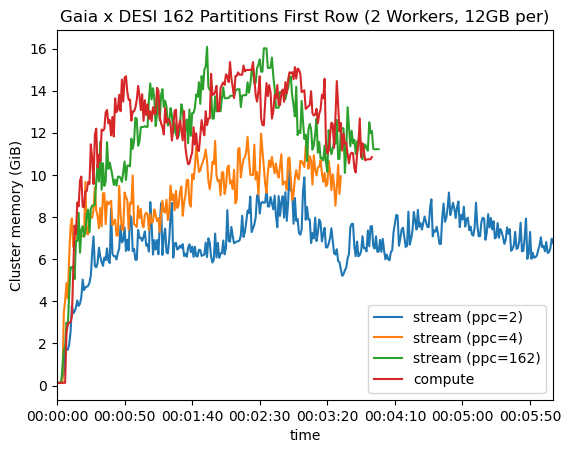

In [12]:
import matplotlib.pyplot as plt
fig = plt.figure(dpi=150)

ms_xmatch.plot(align=True)
ax = plt.gca()
ax.set_title("Gaia x DESI 162 Partitions First Row (2 Workers, 12GB per)")